In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# keras.layers.Dense
# keras.models.Sequential
# tf.keras.optimizers.RMSprop(0.001)

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df.head(5)

,Year,Name,Mileage,Rating,Review Count,Price
0,2021,Mercedes-Benz A-Class A 220 4MATIC,29636,3.9,1800.0,30900.0
1,2022,Mercedes-Benz AMG SL 63 Base,5540,4.7,1239.0,139999.0
2,2022,Mercedes-Benz AMG SL 63 Base,4890,4.7,1239.0,132999.0
3,2020,Mercedes-Benz AMG E 53 Base 4MATIC,29746,4.8,752.0,58587.0
4,2021,Mercedes-Benz AMG GLS 63 Base 4MATIC,32631,5.0,1502.0,95990.0


In [4]:
df = df.drop(columns = ["Name"])

In [5]:
df.head(5)

,Year,Mileage,Rating,Review Count,Price
0,2021,29636,3.9,1800.0,30900.0
1,2022,5540,4.7,1239.0,139999.0
2,2022,4890,4.7,1239.0,132999.0
3,2020,29746,4.8,752.0,58587.0
4,2021,32631,5.0,1502.0,95990.0


In [6]:
df.isna().any()

,0
Year,False
Mileage,False
Rating,True
Review Count,True
Price,True


In [7]:
df = df.dropna()
df.isna().any()

,0
Year,False
Mileage,False
Rating,False
Review Count,False
Price,False


In [8]:
train_dataset, test_dataset = train_test_split(df, test_size = 0.2, random_state = 42)

In [9]:
train_labels = train_dataset.pop("Price")
test_labels = test_dataset.pop("Price")

In [10]:
train_stats = train_dataset.describe()
train_stats = train_stats.transpose()
train_stats

,count,mean,std,min,25%,50%,75%,max
Year,1707.0,2021.792619,1.592146,2015.0,2021.0,2022.0,2023.0,2024.0
Mileage,1707.0,19722.456356,17841.479114,100.0,5537.0,13640.0,30704.0,194043.0
Rating,1707.0,4.537786,0.381544,2.1,4.4,4.6,4.8,5.0
Review Count,1707.0,1408.699473,1240.988883,7.0,526.0,1050.0,1915.0,7140.0


In [11]:
def norm(X):
  return (X - train_stats["mean"]) / train_stats["std"]

In [12]:
normed_train_data = norm(train_dataset)
normed_test_data = norm(test_dataset)

In [13]:
def build_model():
  model = keras.Sequential([
      layers.Dense(16, activation = 'relu', input_shape = [len(train_dataset.keys())]),
      layers.Dense(8, activation = 'relu'),
      layers.Dense(1)
  ])

  optimizer = tf.keras.optimizers.RMSprop(0.001)

  model.compile(optimizer = optimizer, loss = "mse", metrics = ["mse", "mae"])

  return model

In [14]:
model = build_model()
history = model.fit(normed_train_data, train_labels, epochs = 250, validation_split = 0.2, verbose = 0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
hist = pd.DataFrame(history.history)
hist["epoch"] = history.epoch
hist.head()

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
0,4.240602e+09,56852.347656,4.240602e+09,4.391585e+09,56707.960938,4.391585e+09,0
1,4.240479e+09,56851.265625,4.240479e+09,4.391449e+09,56706.707031,4.391449e+09,1
2,4.240322e+09,56849.871094,4.240322e+09,4.391275e+09,56705.121094,4.391275e+09,2
3,4.240123e+09,56848.136719,4.240123e+09,4.391057e+09,56703.164062,4.391057e+09,3
4,4.239876e+09,56845.972656,4.239876e+09,4.390789e+09,56700.765625,4.390789e+09,4


In [25]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist["epoch"] = history.epoch

  plt.figure(figsize = (8, 5))
  plt.plot(hist["epoch"], hist["mse"], label = "Train Error")
  plt.plot(hist["epoch"], hist["val_mse"], label = "Val Error")
  plt.xlabel("Epochs")
  plt.ylabel("MSE")
  plt.grid(True)
  plt.legend()
  plt.show()

  plt.figure(figsize = (8, 5))
  plt.plot(hist["epoch"], hist["mae"], label = "Train Error")
  plt.plot(hist["epoch"], hist["val_mae"], label = "Val Error")
  plt.xlabel("Epochs")
  plt.ylabel("MAE")
  plt.grid(True)
  plt.legend()
  plt.show()

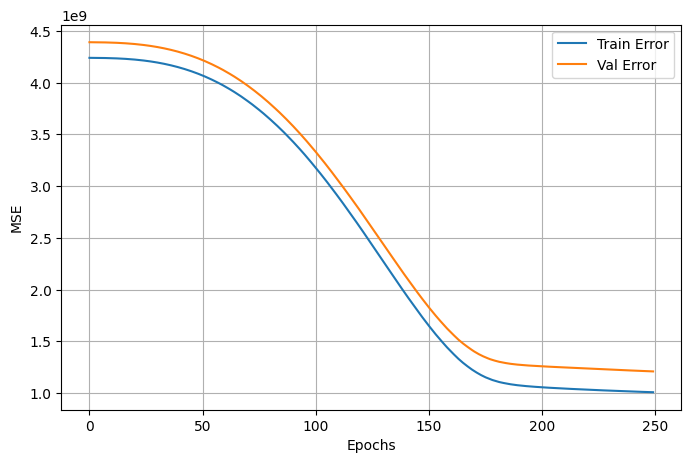

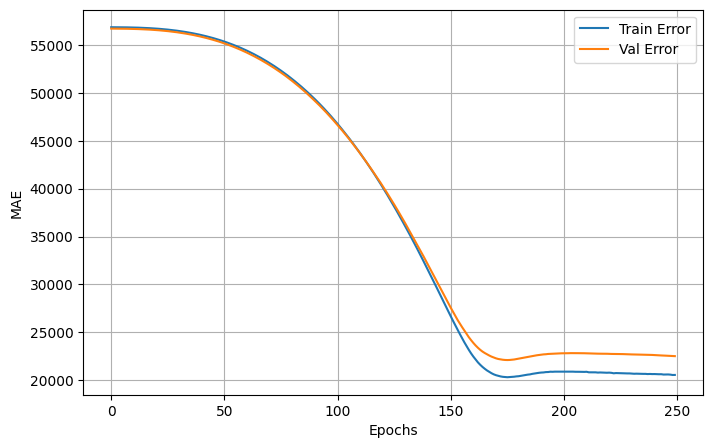

In [26]:
plot_history(history)

In [23]:
loss_value, mse, mae = model.evaluate(normed_test_data, test_labels, verbose = 0)
print("MSE: ", mse)
print("MAE: ", mae)

MSE:  1090283008.0
MAE:  21721.50390625


In [24]:
best_mae_index = int(hist['val_mae'].idxmin())
best_mae_epoch = best_mae_index + 1
last_train_mae = float(hist['mae'].iloc[-1])
last_val_mae = float(hist['val_mae'].iloc[-1])
best_val_mae = float(hist['val_mae'].iloc[best_mae_index])

print(f'Najbolja epoha prema validacionoj MAE: {best_mae_epoch}')
print(f'Najbolja validaciona MAE: {best_val_mae:.4f}')
print(f'Poslednja trening MAE: {last_train_mae:.4f}')
print(f'Poslednja validaciona MAE: {last_val_mae:.4f}')

if last_val_mae > best_val_mae * 1.05 and last_train_mae < float(hist['mae'].iloc[best_mae_index]):
    print('Model pokazuje znake preprilagodjavanja.')
else:
    print('Na osnovu validacione greske nema jakog znaka preprilagodjavanja.')

Najbolja epoha prema validacionoj MAE: 176
Najbolja validaciona MAE: 22102.6309
Poslednja trening MAE: 20548.6816
Poslednja validaciona MAE: 22510.8535
Na osnovu validacione greske nema jakog znaka preprilagodjavanja.
